# 1. Data Ingestion

In [1]:
import pandas as pd
import pandas as pd
# Plotting setup: one shared style so every chart in the notebook looks consistent.
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 10,
})
BLUE, ORANGE, RED, GREY = '#4C78A8', '#F58518', '#E45756', '#9AA5B1'


In [2]:
customers = pd.read_csv('olist_data/olist_customers_dataset.csv')
geolocation = pd.read_csv('olist_data/olist_geolocation_dataset.csv')
order_items = pd.read_csv('olist_data/olist_order_items_dataset.csv')
order_payments = pd.read_csv('olist_data/olist_order_payments_dataset.csv')
order_reviews = pd.read_csv('olist_data/olist_order_reviews_dataset.csv')
orders_dataset = pd.read_csv('olist_data/olist_orders_dataset.csv')
products = pd.read_csv('olist_data/olist_products_dataset.csv')
sellers = pd.read_csv('olist_data/olist_sellers_dataset.csv')
product_category_name_translation = pd.read_csv('olist_data/product_category_name_translation.csv')

In [3]:
t = '=' * 49

# 2. Check Duplicates & Missing Values

In [4]:
# Check for duplicates before modeling or aggregating.
# Duplicate rows would artificially inflate counts, revenue totals, and seller
# volume, which would distort the business findings. We remove them early to keep
# the dataset aligned with the real transactions.

datasets = {
    'customers':customers,
    'geolocation':geolocation,
    'order_items':order_items,
    'order_payments':order_payments,
    'order_reviews':order_reviews,
    'orders_dataset':orders_dataset,
    'products':products,
    'sellers':sellers,
    'product_category_name_translation':product_category_name_translation
}

for name, dataset in datasets.items():
    duplicate_count = dataset.duplicated().sum()
    if duplicate_count:
        print (f'--{name.upper()} have {duplicate_count} duplicates.')
        dataset.drop_duplicates(inplace=True)
        print (f'--Dropped {duplicate_count} rows from {name.upper()}.')
    else:
        print (f'-{name.upper()} have no duplicates.')
    print(t)

-CUSTOMERS have no duplicates.
--GEOLOCATION have 261831 duplicates.
--Dropped 261831 rows from GEOLOCATION.
-ORDER_ITEMS have no duplicates.
-ORDER_PAYMENTS have no duplicates.
-ORDER_REVIEWS have no duplicates.
-ORDERS_DATASET have no duplicates.
-PRODUCTS have no duplicates.
-SELLERS have no duplicates.
-PRODUCT_CATEGORY_NAME_TRANSLATION have no duplicates.


In [5]:
# Review missing values before deciding how to handle them.
# Missing data is not always a problem, but it can affect the validity of the
# analysis if we ignore it. This step tells us whether we need to fill values,
# keep nulls, or limit the scope of a metric.

for name, dataset in datasets.items():
    null_rows = dataset.isna().sum()
    missing_vals = null_rows[null_rows > 0]
    print (f'========== {name.upper()} Missing Values ==========')
    if not missing_vals.empty:
        print(missing_vals)
        print(f'\n-Missing Values Percents: \n{round(missing_vals / dataset.shape[0] * 100, 2)}')
    else:
        print ('NO Missing Values.')
    print('_' * 49+'\n')

========== CUSTOMERS Missing Values ==========
NO Missing Values.
_________________________________________________

========== GEOLOCATION Missing Values ==========
NO Missing Values.
_________________________________________________

========== ORDER_ITEMS Missing Values ==========
NO Missing Values.
_________________________________________________

========== ORDER_PAYMENTS Missing Values ==========
NO Missing Values.
_________________________________________________

========== ORDER_REVIEWS Missing Values ==========
review_comment_title      87656
review_comment_message    58247
dtype: int64

-Missing Values Percents: 
review_comment_title      88.34
review_comment_message    58.70
dtype: float64
_________________________________________________

========== ORDERS_DATASET Missing Values ==========
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64

-Missing Values Percents: 
order_approved_at             

In [6]:
orders_dataset[orders_dataset.order_delivered_customer_date.isna()].groupby('order_status').order_id.count()
# Missing dates align with natural order status so it won't be removed because deleting them would affect the analysis ahead 

order_status
approved          2
canceled        619
created           5
delivered         8
invoiced        314
processing      301
shipped        1107
unavailable     609
Name: order_id, dtype: int64

# 3. Handling Missing values

## 3.1 Products

In [7]:
# Products are linked to real sales and revenue so we keep the null names while changing their values to 'unknown'
products.fillna({'product_category_name':'unknown'}, inplace = True)

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0
...,...,...,...,...,...,...,...,...,...
32946,a0b7d5a992ccda646f2d34e418fff5a0,moveis_decoracao,45.0,67.0,2.0,12300.0,40.0,40.0,40.0
32947,bf4538d88321d0fd4412a93c974510e6,construcao_ferramentas_iluminacao,41.0,971.0,1.0,1700.0,16.0,19.0,16.0
32948,9a7c6041fa9592d9d9ef6cfe62a71f8c,cama_mesa_banho,50.0,799.0,1.0,1400.0,27.0,7.0,27.0
32949,83808703fc0706a22e264b9d75f04a2e,informatica_acessorios,60.0,156.0,2.0,700.0,31.0,13.0,20.0


In [8]:
# Fill missing numbers (weights, sizes, photo quantities) with 0 to keep data types consistent.
# We can't fill data with mean/median because every product is different and there are too many products for Group-wise (Subgroup) Imputation
empty_product_numeric_cols = ['product_name_lenght',
                                'product_description_lenght',
                                'product_photos_qty',
                                'product_weight_g',
                                'product_length_cm',
                                'product_height_cm',
                                'product_width_cm']
for col in empty_product_numeric_cols:
    products.fillna({col:0}, inplace=True)
products.isna().sum()

product_id                    0
product_category_name         0
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              0
product_length_cm             0
product_height_cm             0
product_width_cm              0
dtype: int64

## 3.2 Order_Reviews

In [9]:
# Fill review text fields with placeholders instead of removing reviews.
# Reviews without a title or comment are still valid customer feedback.
# We preserve those rows because review score is part of the quality signal and
# dropping them would reduce the sample and bias the sentiment analysis.

order_reviews.fillna({'review_comment_title':'No Title',
                    'review_comment_message':'No Message'}, inplace=True)
order_reviews.isna().sum()

review_id                  0
order_id                   0
review_score               0
review_comment_title       0
review_comment_message     0
review_creation_date       0
review_answer_timestamp    0
dtype: int64

# 4. Data Types

In [10]:
for name, dataset in datasets.items():
    print (f'========== {name.upper()} Data Types ==========')
    print(dataset.dtypes)
    print(t)

========== CUSTOMERS Data Types ==========
customer_id                   str
customer_unique_id            str
customer_zip_code_prefix    int64
customer_city                 str
customer_state                str
dtype: object
========== GEOLOCATION Data Types ==========
geolocation_zip_code_prefix      int64
geolocation_lat                float64
geolocation_lng                float64
geolocation_city                   str
geolocation_state                  str
dtype: object
========== ORDER_ITEMS Data Types ==========
order_id                   str
order_item_id            int64
product_id                 str
seller_id                  str
shipping_limit_date        str
price                  float64
freight_value          float64
dtype: object
========== ORDER_PAYMENTS Data Types ==========
order_id                    str
payment_sequential        int64
payment_type                str
payment_installments      int64
payment_value           float64
dtype: object
========== ORDER_REVI

## 4.1 Fix The Dates Data types To Enable Time-based Analysis

In [11]:
# Convert date-like columns to datetime.
# Time-based metrics such as approval delay, total delivery time, and forecast error
# require proper datetime types. Without this conversion, we cannot calculate
# durations reliably or compare actual vs estimated delivery performance.

order_items.shipping_limit_date = pd.to_datetime(order_items.shipping_limit_date)
order_reviews.review_answer_timestamp = pd.to_datetime(order_reviews.review_answer_timestamp)

str_to_date = ['order_purchase_timestamp',
                'order_approved_at',
                'order_delivered_carrier_date',
                'order_delivered_customer_date',
                'order_estimated_delivery_date']
for date in str_to_date:
    orders_dataset[date] = pd.to_datetime(orders_dataset[date])

display(orders_dataset.dtypes, order_items.dtypes, order_reviews.dtypes)

order_id                                    str
customer_id                                 str
order_status                                str
order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object

order_id                          str
order_item_id                   int64
product_id                        str
seller_id                         str
shipping_limit_date    datetime64[us]
price                         float64
freight_value                 float64
dtype: object

review_id                             str
order_id                              str
review_score                        int64
review_comment_title                  str
review_comment_message                str
review_creation_date                  str
review_answer_timestamp    datetime64[us]
dtype: object

# 5. Assessing the Data size

In [12]:
for name, dataset in datasets.items():
    print (f'========== {name.upper()} Shape ==========')
    print(dataset.shape)
    print('_' * 40+'\n')

========== CUSTOMERS Shape ==========
(99441, 5)
________________________________________

========== GEOLOCATION Shape ==========
(738332, 5)
________________________________________

========== ORDER_ITEMS Shape ==========
(112650, 7)
________________________________________

========== ORDER_PAYMENTS Shape ==========
(103886, 5)
________________________________________

========== ORDER_REVIEWS Shape ==========
(99224, 7)
________________________________________

========== ORDERS_DATASET Shape ==========
(99441, 8)
________________________________________

========== PRODUCTS Shape ==========
(32951, 9)
________________________________________

========== SELLERS Shape ==========
(3095, 4)
________________________________________

========== PRODUCT_CATEGORY_NAME_TRANSLATION Shape ==========
(71, 2)
________________________________________



## 5.1 Compressing Geolocation data
It has almost 1M rows because it includes the coordinates of a lot of similar locations with only a few meters difference.

In [13]:
geo_cleaned = geolocation.groupby('geolocation_zip_code_prefix').agg({'geolocation_lat':'mean',
                                                        'geolocation_lng':'mean',
                                                        'geolocation_city':'first',
                                                        'geolocation_state':'first'}).reset_index()

print(f'Compressed geolocation: {len(geolocation)} rows To geo_cleaned: {len(geo_cleaned)}')

geo_cleaned.columns = ['zip_code_prefix', 'lat', 'lng', 'city', 'state']

geo_cleaned.head()

Compressed geolocation: 738332 rows To geo_cleaned: 19015


,zip_code_prefix,lat,lng,city,state
0,1001,-23.550227,-46.634039,sao paulo,SP
1,1002,-23.547657,-46.634991,sao paulo,SP
2,1003,-23.549000,-46.635582,sao paulo,SP
3,1004,-23.549829,-46.634792,sao paulo,SP
4,1005,-23.549547,-46.636406,sao paulo,SP


# 6. Exploratory Data Analysis

## 6.1 Orders Dates

In [14]:
# Create stage-by-stage duration columns.
# These metrics help assess where delays happen in the order lifecycle:
# approval, carrier handoff, and last-mile delivery. This makes it possible to
# separate process friction from final delivery performance.

# -Time between order purchase and approval
orders_dataset['approval_duration'] = orders_dataset.order_approved_at - orders_dataset.order_purchase_timestamp
# -Time between approval and carrier delivery
orders_dataset['from_approval_to_carrier'] = orders_dataset.order_delivered_carrier_date - orders_dataset.order_approved_at
# -Time between carrier delivery and customer receipt
orders_dataset['from_carrier_to_customer'] = orders_dataset.order_delivered_customer_date - orders_dataset.order_delivered_carrier_date
# -Total time from purchase to customer receipt
orders_dataset['total_delivery_duration'] = orders_dataset.order_delivered_customer_date - orders_dataset.order_purchase_timestamp
# -Time from purchase to estimated delivery
orders_dataset['estimation_to_delivery_duration'] = orders_dataset.order_estimated_delivery_date - orders_dataset.order_purchase_timestamp
# -Difference between actual delivery and estimated delivery
orders_dataset['estimation_to_delivery_error'] = orders_dataset.order_delivered_customer_date - orders_dataset.order_estimated_delivery_date

orders_dataset[['order_id','approval_duration','from_approval_to_carrier','from_carrier_to_customer','total_delivery_duration','estimation_to_delivery_duration','estimation_to_delivery_error']]

,order_id,approval_duration,from_approval_to_carrier,from_carrier_to_customer,total_delivery_duration,estimation_to_delivery_duration,estimation_to_delivery_error
0,e481f51cbdc54678b7cc49136f2d6af7,0 days 00:10:42,2 days 08:47:45,6 days 01:30:13,8 days 10:28:40,15 days 13:03:27,-8 days +21:25:13
1,53cdb2fc8bc7dce0b6741e2150273451,1 days 06:42:50,0 days 11:06:33,12 days 00:56:45,13 days 18:46:08,19 days 03:18:23,-6 days +15:27:45
2,47770eb9100c2d0c44946d9cf07ec65d,0 days 00:16:34,0 days 04:54:37,9 days 04:16:29,9 days 09:27:40,26 days 15:21:11,-18 days +18:06:29
3,949d5b44dbf5de918fe9c16f97b45f8a,0 days 00:17:53,3 days 17:54:00,9 days 10:48:43,13 days 05:00:36,26 days 04:31:54,-13 days +00:28:42
4,ad21c59c0840e6cb83a9ceb5573f8159,0 days 01:01:50,0 days 21:26:05,1 days 22:30:28,2 days 20:58:23,12 days 02:41:21,-10 days +18:17:02
...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,0 days 00:00:00,1 days 01:23:58,7 days 03:49:58,8 days 05:13:56,18 days 14:05:55,-11 days +15:08:01
99437,63943bddc261676b46f01ca7ac2f7bd8,0 days 00:11:39,1 days 10:12:05,20 days 18:15:14,22 days 04:38:58,23 days 11:01:02,-2 days +17:37:56
99438,83c1379a015df1e13d02aae0204711ab,0 days 00:17:33,1 days 05:48:10,23 days 14:31:51,24 days 20:37:34,30 days 09:13:17,-6 days +11:24:17
99439,11c177c8e97725db2631073c19f07b62,0 days 00:07:54,3 days 17:58:42,13 days 07:57:51,17 days 02:04:27,37 days 02:31:33,-21 days +23:32:54


In [15]:
# Aggregate delivery timing by customer state.
# This identifies regional differences in order performance and helps pinpoint
# whether late deliveries are concentrated in certain states rather than spread
# evenly across the network.

customers_orders = pd.merge(customers, orders_dataset, on='customer_id', how='left').reset_index()
customers_orders_delivered = customers_orders[customers_orders['order_status'] == 'delivered']

orders_dates_analysis = customers_orders_delivered.groupby(
                                            'customer_state').agg({
                                            'approval_duration': 'mean',
                                            'from_approval_to_carrier': 'mean',
                                            'from_carrier_to_customer': 'mean',
                                            'total_delivery_duration': 'mean',
                                            'estimation_to_delivery_error': 'mean'})

duration_columns = [
    'approval_duration',
    'from_approval_to_carrier',
    'from_carrier_to_customer',
    'total_delivery_duration',
    'estimation_to_delivery_error']

orders_dates_analysis[duration_columns] = (
    orders_dates_analysis[duration_columns]
    .apply(lambda column: column.dt.total_seconds() / 86400)
    .round(2))

orders_dates_analysis.rename(columns={'approval_duration':'avg_approval_duration',
                                    'from_approval_to_carrier':'avg_from_approval_to_carrier',
                                    'from_carrier_to_customer':'avg_from_carrier_to_customer',
                                    'total_delivery_duration':'avg_total_delivery_duration',
                                    'estimation_to_delivery_error':'avg_estimation_to_delivery_error'}, inplace=True)

orders_dates_analysis.sort_values('avg_estimation_to_delivery_error', ascending=False, inplace=True)

In [16]:
orders_dates_analysis

,avg_approval_duration,avg_from_approval_to_carrier,avg_from_carrier_to_customer,avg_total_delivery_duration,avg_estimation_to_delivery_error
customer_state,,,,,
AL,0.49,2.97,21.09,24.54,-8.03
MA,0.58,3.02,17.97,21.57,-8.89
SE,0.42,3.15,17.95,21.52,-9.33
ES,0.44,2.94,12.41,15.79,-9.80
BA,0.49,2.81,16.04,19.34,-10.10
CE,0.47,2.86,17.93,21.27,-10.11
MS,0.44,2.73,12.45,15.62,-10.36
SP,0.41,2.76,5.60,8.76,-10.38
PI,0.42,2.76,16.28,19.46,-10.63


### Chart: Where does delivery time accumulate?

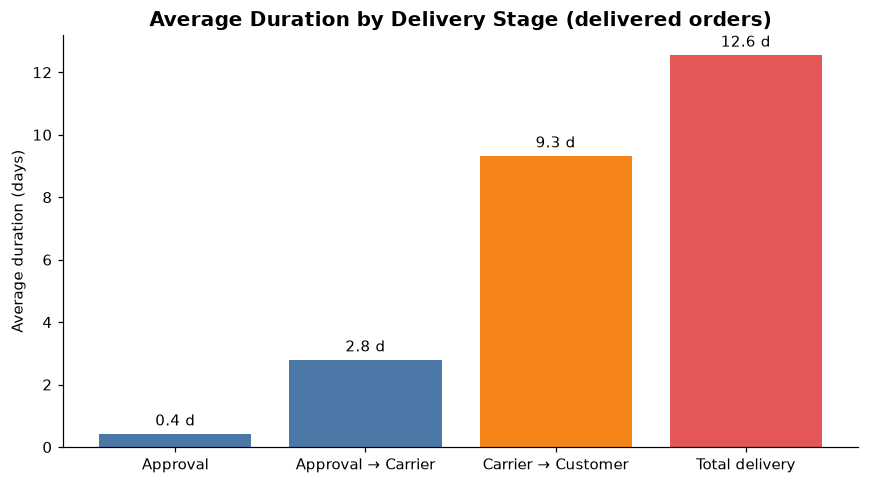

In [17]:
# Average duration of each stage across delivered orders only.
# This answers the bottleneck question: which step of the journey takes the most time.
# "Total delivery" is shown in a different color because it is the sum of the stages
# (plus small gaps), not a separate stage.

delivered_orders = orders_dataset[orders_dataset['order_status'] == 'delivered']

stage_columns = {
    'Approval':            'approval_duration',
    'Approval → Carrier':  'from_approval_to_carrier',
    'Carrier → Customer':  'from_carrier_to_customer',
    'Total delivery':      'total_delivery_duration',
}

stage_days = pd.Series({
    label: delivered_orders[col].dt.total_seconds().mean() / 86400
    for label, col in stage_columns.items()
})

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(stage_days.index, stage_days.values,
            color=[BLUE, BLUE, ORANGE, RED])
ax.bar_label(bars, fmt='%.1f d', padding=3)
ax.set_ylabel('Average duration (days)')
ax.set_title('Average Duration by Delivery Stage (delivered orders)')
plt.tight_layout()
plt.show()


## 6.2 Payment & Freight
Potential payment/order-total inconsistencies requiring investigation.

In [18]:
# Compare order payment totals against the product + freight totals.
# This check is important because a mismatch between what customers paid and what
# the order items total suggests data quality issues, payment anomalies, or
# incorrect item aggregation. We investigate these before making business claims.

order_items_total = order_items.groupby('order_id')[['price','freight_value']].sum().reset_index()
order_payment_total = order_payments.groupby('order_id').payment_value.sum().reset_index()

orders_totals = pd.merge(order_items_total, order_payment_total, on='order_id', how='left')

orders_totals['price'] = round(orders_totals.price, 2)
orders_totals['freight_value'] = round(orders_totals.freight_value, 2)
orders_totals['payment_value'] = round(orders_totals.payment_value, 2)

orders_totals.rename(columns={'price':'items_total', 'freight_value':'freight_total', 'payment_value':'payment_total'}, inplace=True)

orders_totals['order_total'] = round(orders_totals.items_total + orders_totals.freight_total, 2)
orders_totals['payment_minus_order'] = round(orders_totals.payment_total - orders_totals.order_total, 2)

orders_totals[orders_totals.payment_minus_order != 0].sort_values('payment_minus_order', ascending=True)

,order_id,items_total,freight_total,payment_total,order_total,payment_minus_order
14628,262118ce178bb3e4590a3adcf6d62e6b,119.80,57.94,126.12,177.74,-51.62
97606,fd33085945f15975375cd8ec85440511,217.99,16.63,212.82,234.62,-21.80
42504,6e57e23ecac1ae881286657694444267,330.00,20.41,333.91,350.41,-16.50
25102,4154bf1348caac78152fe76e3e9c4af8,149.90,15.36,150.27,165.26,-14.99
42292,6dcf0aeb8b1eb4021c26e1d0e9394979,299.00,34.92,318.97,333.92,-14.95
...,...,...,...,...,...,...
58752,996c7e73600ad3723e8627ab7bef81e4,559.90,28.00,664.43,587.90,76.53
43434,70b742795bc441e94a44a084b6d9ce7a,269.99,196.94,578.82,466.93,111.89
42515,6e5fe7366a2e1bfbf3257dba0af1267f,179.19,108.72,406.92,287.91,119.01
79538,ce6d150fb29ada17d2082f4847107665,1299.00,104.66,1586.47,1403.66,182.81


In [19]:
print(f"Total Positive payment difference: ${(orders_totals[orders_totals.payment_minus_order > 0]['payment_minus_order'].sum()):,.2f}")
print(f"Total Negative payment difference: ${(orders_totals[orders_totals.payment_minus_order < 0]['payment_minus_order'].sum()):,.2f}")
print(f"Total payment difference:          ${(orders_totals['payment_minus_order'].sum()):,.2f}")

Total Positive payment difference: $3,071.17
Total Negative payment difference: $-200.78
Total payment difference:          $2,870.39


### Chart: Payment vs. order-total differences

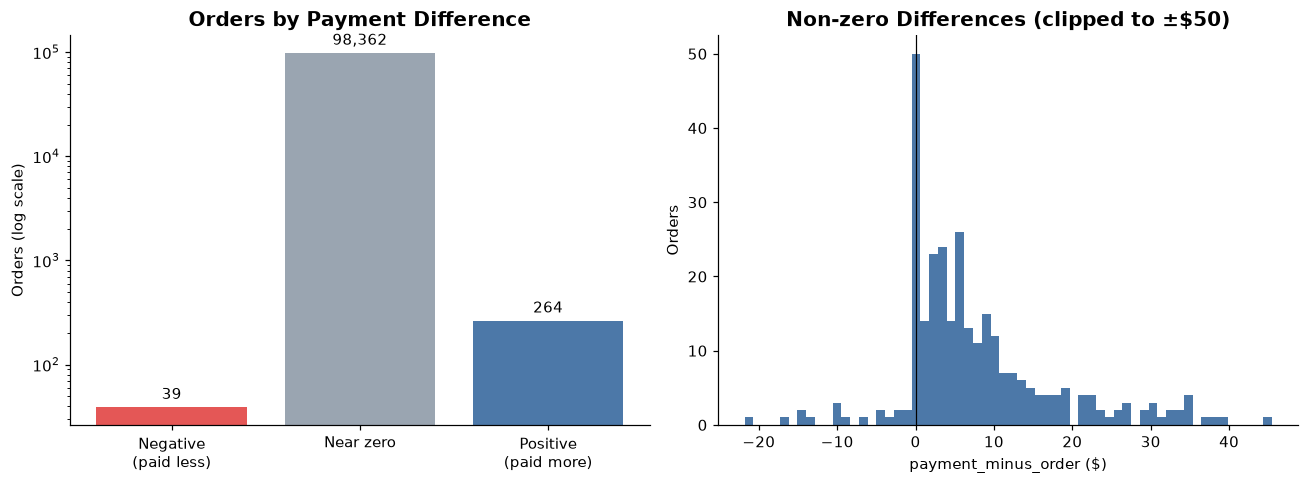

In [20]:
# Classify each order by the sign of (payment - order total).
# Values are rounded to cents, so anything within 1 cent is treated as "near zero".
# Left: how many orders fall in each group (log scale, because near-zero dominates).
# Right: the size of the non-zero differences, clipped to +/- $50 so outliers do not
# flatten the histogram.

diff = orders_totals['payment_minus_order'].dropna()

def reconciliation_group(x):
    if x < -0.01:
        return 'Negative\n(paid less)'
    if x > 0.01:
        return 'Positive\n(paid more)'
    return 'Near zero'

group_counts = (diff.apply(reconciliation_group)
                    .value_counts()
                    .reindex(['Negative\n(paid less)', 'Near zero', 'Positive\n(paid more)'])
                    .fillna(0))

nonzero_diff = diff[(diff.abs() > 0.01) & (diff.abs() <= 50)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

bars = axes[0].bar(group_counts.index, group_counts.values, color=[RED, GREY, BLUE])
axes[0].set_yscale('log')
axes[0].bar_label(bars, fmt='{:,.0f}', padding=3)
axes[0].set_ylabel('Orders (log scale)')
axes[0].set_title('Orders by Payment Difference')

axes[1].hist(nonzero_diff, bins=60, color=BLUE)
axes[1].axvline(0, color='black', lw=0.8)
axes[1].set_xlabel('payment_minus_order ($)')
axes[1].set_ylabel('Orders')
axes[1].set_title('Non-zero Differences (clipped to ±$50)')

plt.tight_layout()
plt.show()


In [21]:
# Summarize revenue and freight by customer state.
# This helps identify whether certain regions generate more revenue or carry
# unusually high shipping costs, which matters for pricing and logistics strategy.

order_totals_state = pd.merge(orders_totals[['order_id','freight_total','items_total']], customers_orders[['order_id','customer_state']], on='order_id', how='left')

revenue_and_freight_summary = order_totals_state.groupby('customer_state').agg(
                                                    total_product_revenue=('items_total', lambda x: round(x.sum(), 2)),
                                                    total_freight=('freight_total', lambda x: round(x.sum(), 2)),
                                                    avg_freight=('freight_total', lambda x: round(x.mean(), 2)),
                                                    freight_median=('freight_total', lambda x: round(x.median(), 2)),
                                                    freight_std=('freight_total', lambda x: round(x.std(), 2))).sort_values('total_product_revenue', ascending=False).reset_index()

revenue_and_freight_summary['freight_coefficient_of_variation'] = round(revenue_and_freight_summary['freight_std'] / revenue_and_freight_summary['avg_freight'], 2)

display(revenue_and_freight_summary)

,customer_state,total_product_revenue,total_freight,avg_freight,freight_median,freight_std,freight_coefficient_of_variation
0,SP,5202955.05,718723.07,17.37,13.61,14.91,0.86
1,RJ,1824092.67,305589.31,23.95,17.95,19.70,0.82
2,MG,1585308.03,270853.46,23.46,18.16,18.37,0.78
3,RS,750304.02,135522.74,24.95,18.23,20.32,0.81
4,PR,683083.76,117851.68,23.58,17.88,24.50,1.04
5,SC,520553.34,89660.26,24.82,18.23,21.53,0.87
6,BA,511349.99,100156.68,29.83,22.06,29.01,0.97
7,DF,302603.94,50625.50,23.82,18.09,18.25,0.77
8,GO,294591.95,53114.98,26.46,18.51,24.93,0.94
9,ES,275037.31,49764.60,24.58,18.28,19.51,0.79


### Charts: Revenue and freight by state

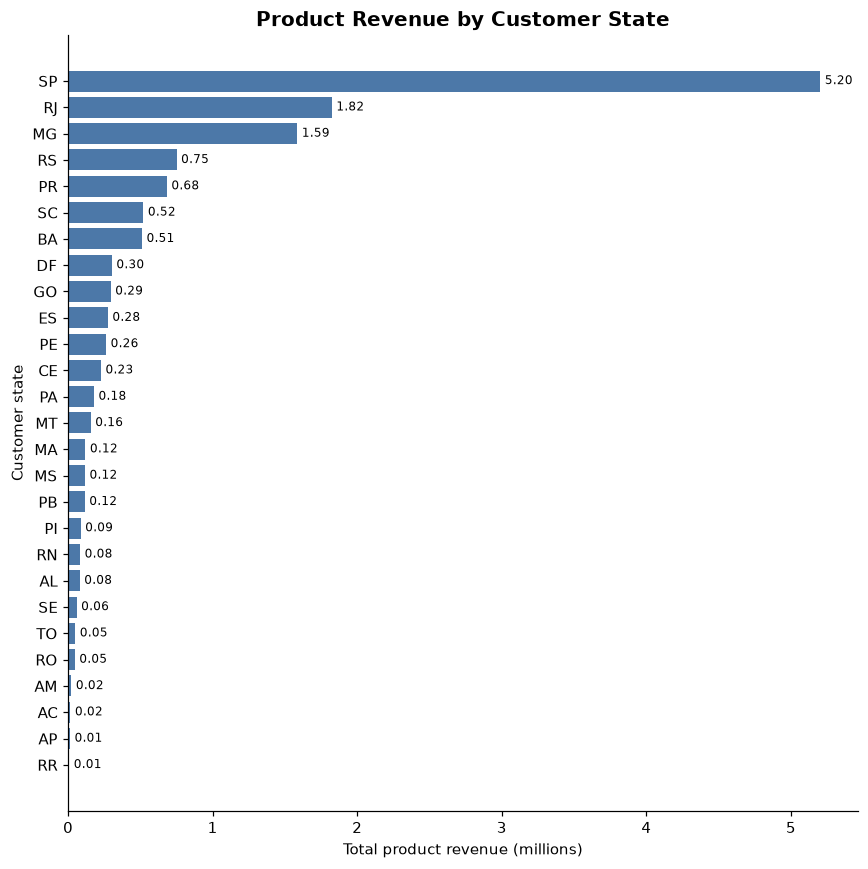

In [22]:
# Two separate charts on purpose: revenue (millions) and freight (tens of dollars)
# live on very different scales, so combining them would hide the freight pattern.

revenue_plot = revenue_and_freight_summary.sort_values('total_product_revenue')

fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(revenue_plot['customer_state'], revenue_plot['total_product_revenue'] / 1e6, color=BLUE)
ax.bar_label(ax.containers[0], fmt='%.2f', padding=3, fontsize=8)
ax.set_xlabel('Total product revenue (millions)')
ax.set_ylabel('Customer state')
ax.set_title('Product Revenue by Customer State')
plt.tight_layout()
plt.show()


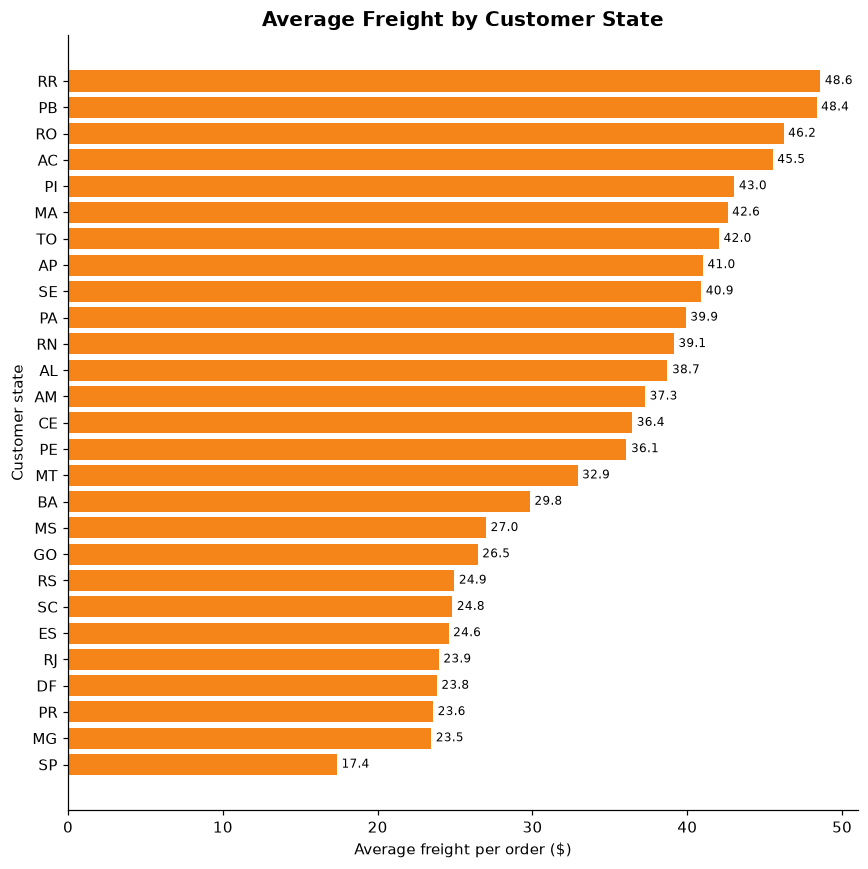

In [23]:
freight_plot = revenue_and_freight_summary.sort_values('avg_freight')

fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(freight_plot['customer_state'], freight_plot['avg_freight'], color=ORANGE)
ax.bar_label(ax.containers[0], fmt='%.1f', padding=3, fontsize=8)
ax.set_xlabel('Average freight per order ($)')
ax.set_ylabel('Customer state')
ax.set_title('Average Freight by Customer State')
plt.tight_layout()
plt.show()


## 6.3 Order Reviews & Delays

In [24]:
review_score_distribution = round(order_reviews.groupby('review_score', sort=True).order_id.count() / order_reviews.order_id.count() * 100, 2).sort_values(ascending=False)

review_score_distribution.rename('orders_distribution_pct', inplace=True)

review_score
5    57.78
4    19.29
1    11.51
3     8.24
2     3.18
Name: orders_distribution_pct, dtype: float64

In [25]:
# Measure how review scores change with delivery performance.
# This links customer experience to operational timing. If late or very late
# deliveries consistently receive lower scores, that indicates a clear business
# problem affecting satisfaction and retention.

review_score_and_delays = pd.merge(order_reviews[['order_id','review_score']], orders_dataset[['order_id','estimation_to_delivery_error']], on='order_id', how='left').reset_index()

def delivery_categorization(x):
    if pd.isna(x):
        return 'unknown'
    delay_days = x.total_seconds() / 86400
    if delay_days < 0:
        return 'early'
    if delay_days == 0:
        return 'on_time'
    if delay_days <= 4:
        return 'late'
    return 'very_late'

review_score_and_delays['delivery_status'] = review_score_and_delays.estimation_to_delivery_error.apply(delivery_categorization)

review_score_and_delays = review_score_and_delays.groupby('delivery_status').agg(orders_count=(('order_id', 'count')),
                                                    avg_review_score=('review_score', lambda x: round(x.mean(), 2))).sort_values('avg_review_score', ascending=False).reset_index()

review_score_and_delays

,delivery_status,orders_count,avg_review_score
0,early,88658,4.29
1,late,3147,3.59
2,very_late,4554,1.86
3,unknown,2865,1.76


### Chart: Review score by delivery status

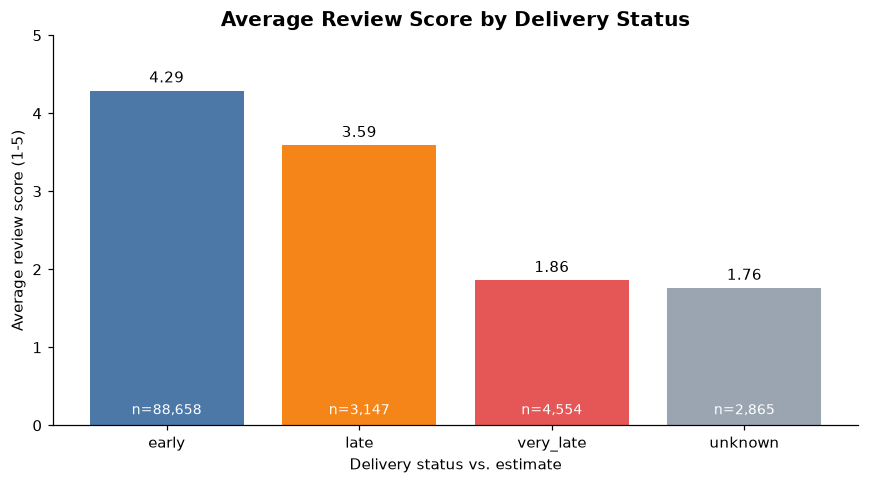

In [26]:
# Average review score for each delivery-status group.
# This is the clearest link between operations and customer satisfaction.
# Groups with no orders (e.g. exactly on time) are skipped automatically.

status_order = ['early', 'on_time', 'late', 'very_late', 'unknown']
review_plot = (review_score_and_delays
            .set_index('delivery_status')
            .reindex(status_order)
            .dropna(subset=['avg_review_score']))

colors = {'early': BLUE, 'on_time': BLUE, 'late': ORANGE, 'very_late': RED, 'unknown': GREY}

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(review_plot.index, review_plot['avg_review_score'],
              color=[colors[s] for s in review_plot.index])
ax.bar_label(bars, fmt='%.2f', padding=3)
for bar, n in zip(bars, review_plot['orders_count']):
    ax.text(bar.get_x() + bar.get_width() / 2, 0.1, f'n={int(n):,}',
            ha='center', va='bottom', color='white', fontsize=9)
ax.set_ylim(0, 5)
ax.set_ylabel('Average review score (1-5)')
ax.set_xlabel('Delivery status vs. estimate')
ax.set_title('Average Review Score by Delivery Status')
plt.tight_layout()
plt.show()


## 6.4 Seller-level performance

In [27]:
# Rank sellers by delivery error only among delivered orders.
# We do not include all orders because cancelled or non-delivered orders would
# distort the metric. The goal is to isolate sellers whose actual delivery
# performance is systematically worse than the estimated shipment window.

seller_order_delivery = (
    order_items[['order_id', 'seller_id']]
    .drop_duplicates()
    .merge(
        orders_dataset[orders_dataset['order_status'] == 'delivered'][['order_id', 'estimation_to_delivery_error']],
        on='order_id',
        how='inner')
    .groupby('seller_id')
    .agg(
        delivered_orders=('order_id', 'count'),
        avg_estimation_to_delivery_error_days=(
            'estimation_to_delivery_error',
            lambda s: round((s.dt.total_seconds() / 86400).mean(), 2)))
    .reset_index()
    .sort_values('avg_estimation_to_delivery_error_days', ascending=False))

seller_performance = (
    sellers[['seller_id', 'seller_city', 'seller_state']]
    .merge(seller_order_delivery, on='seller_id', how='left')
    .sort_values('avg_estimation_to_delivery_error_days', ascending=False))

seller_performance

,seller_id,seller_city,seller_state,delivered_orders,avg_estimation_to_delivery_error_days
2929,df683dfda87bf71ac3fc63063fba369d,farroupilha,RS,1.0,167.71
1744,e09887ca8c7bf8a4621ce481820414ef,sao paulo,SP,2.0,41.77
2269,8e670472e453ba34a379331513d6aab1,juiz de fora,MG,1.0,35.71
2601,4fb41dff7c50136976d1a5cf004a42e2,feira de santana,BA,3.0,33.82
1001,8629a7efec1aab257e58cda559f03ba7,goiania,GO,1.0,33.81
...,...,...,...,...,...
2871,62d977e2b2aee830de3e039a28490d12,curitiba,PR,NaN,NaN
2935,6576fd3e23c88f0e5d4d23f39bba0542,taboao da serra,SP,NaN,NaN
2969,4f40d2ed38d1cc945364a7cd202a82c7,sao paulo,SP,NaN,NaN
2997,4ce6e5f6c52515177e18c1c9361d8677,sao bernardo do campo,SP,NaN,NaN


### Chart: Seller delivery error (top and bottom 10)

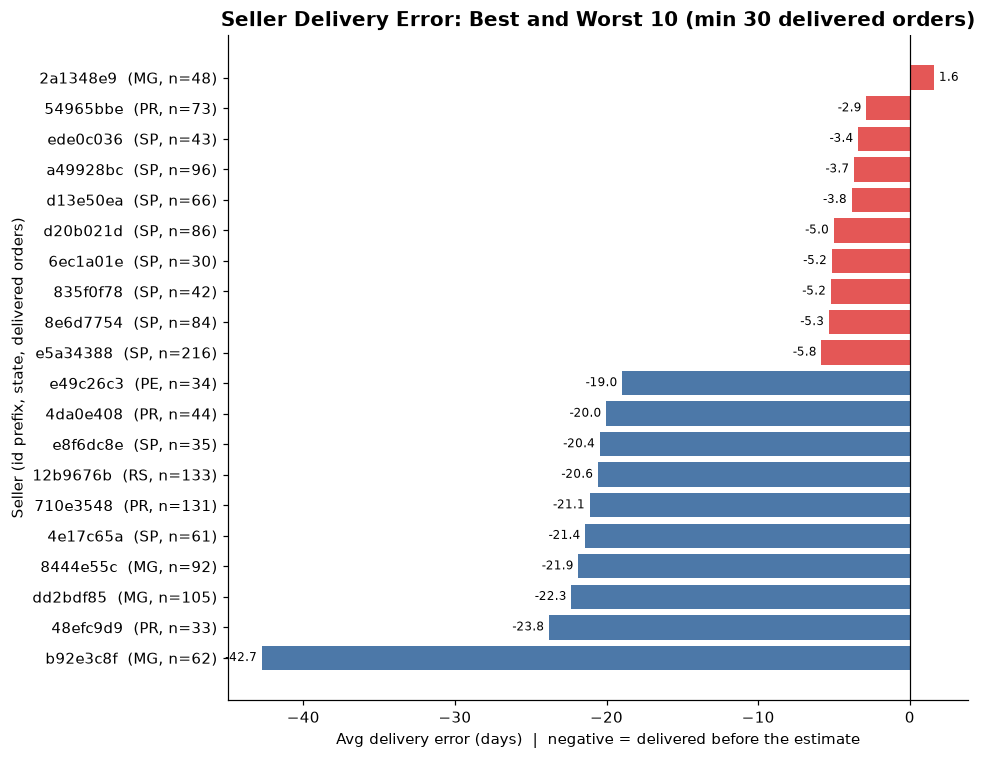

627 of 2970 sellers with delivered orders meet the 30-order threshold.


In [28]:
# Sellers with only a handful of delivered orders produce extreme averages, so we
# keep only sellers with at least MIN_ORDERS delivered orders before ranking.
# Then we show the 10 sellers with the largest error (worst) and the 10 with the
# smallest error (best). Error is in days: negative = delivered before the estimate.

MIN_ORDERS = 30
TOP_N = 10

eligible_sellers = (seller_performance
                    .dropna(subset=['delivered_orders'])
                    .query('delivered_orders >= @MIN_ORDERS')
                    .sort_values('avg_estimation_to_delivery_error_days', ascending=False))

plot_sellers = pd.concat([eligible_sellers.head(TOP_N), eligible_sellers.tail(TOP_N)]).drop_duplicates('seller_id')
plot_sellers = plot_sellers.sort_values('avg_estimation_to_delivery_error_days')

labels = [f"{sid[:8]}  ({state}, n={int(n)})"
          for sid, state, n in zip(plot_sellers.seller_id, plot_sellers.seller_state, plot_sellers.delivered_orders)]
median_error = eligible_sellers['avg_estimation_to_delivery_error_days'].median()
bar_colors = [RED if v > median_error else BLUE for v in plot_sellers['avg_estimation_to_delivery_error_days']]

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(labels, plot_sellers['avg_estimation_to_delivery_error_days'], color=bar_colors)
ax.axvline(0, color='black', lw=0.8)
ax.bar_label(ax.containers[0], fmt='%.1f', padding=3, fontsize=8)
ax.set_xlabel('Avg delivery error (days)  |  negative = delivered before the estimate')
ax.set_ylabel('Seller (id prefix, state, delivered orders)')
ax.set_title(f'Seller Delivery Error: Best and Worst {TOP_N} (min {MIN_ORDERS} delivered orders)')
plt.tight_layout()
plt.show()
print(f'{len(eligible_sellers)} of {seller_performance.delivered_orders.notna().sum()} sellers with delivered orders meet the {MIN_ORDERS}-order threshold.')


# Next Steps....

## Exporting to SQL